In [1]:
import numpy
import pandas
from src.data_objects import AllData
from src.functions import *
import os

retrain = False
runchain = False
logTrain = True
scikit = False

ThisData = AllData
ThisData["name"] = "no-protons"

model_par = "input/noProtons.txt"
outdir = "/data/rjfgroup/rjf01/cameron.parker/tunes/" + ThisData["name"] + "/"

try:
    os.mkdir(outdir)
except:
    print("Output dir exists, will be overwritten")

Output dir exists, will be overwritten


Trimming points and obs ranges

In [2]:
#doesnt converge
del ThisData["Observables"]["PrPr200"]["kaon-pT-soft"]
del ThisData["Observables"]["PrPr200"]["proton-pT-soft"]
del ThisData["Observables"]["PrPr200"]["pion-pT-hard"]

#del ThisData["Observables"]["PrPr2760"]["charged-pT-soft"]
del ThisData["Observables"]["PrPr2760"]["charged-pT-hard"]
del ThisData["Observables"]["PrPr2760"]["pion-pT-hard"]
del ThisData["Observables"]["PrPr2760"]["kaon-pT-soft"]
del ThisData["Observables"]["PrPr2760"]["kaon-pT-hard"]
del ThisData["Observables"]["PrPr2760"]["proton-pT-soft"]
del ThisData["Observables"]["PrPr2760"]["proton-pT-hard"]

del ThisData["Observables"]["PrPr13000"]["pion-pT-hard"]
del ThisData["Observables"]["PrPr13000"]["kaon-pT-soft"]
del ThisData["Observables"]["PrPr13000"]["kaon-pT-hard"]
del ThisData["Observables"]["PrPr13000"]["proton-pT-soft"]
del ThisData["Observables"]["PrPr13000"]["proton-pT-hard"]
del ThisData["Observables"]["PrPr13000"]["mid-y-jets"]
del ThisData["Observables"]["PrPr13000"]["high-y-jets"]

del ThisData["Observables"]["EpEm91"]["charged-xp"]
del ThisData["Observables"]["EpEm91"]["proton-xp"]

#del ThisData["Observables"]["PrPr200"]
#del ThisData["Observables"]["PrPr2760"]
#del ThisData["Observables"]["PrPr13000"]
#del ThisData["Observables"]["EpEm91"]

trimRanges(ThisData)

In [3]:
badpoints = []
trimPoints(badpoints,ThisData)

Making Data pkl for selected observables

In [4]:
buildDataPkl(ThisData, logTrain)
print(ThisData["datapkl"])

Data sets being added to pkl:
EpEm91pion-xp
EpEm91kaon-xp
EpEm91jets
EpEm91mult
PrPr2760charged-pT-soft
PrPr2760pion-pT-soft
PrPr2760jets-R2
PrPr2760jets-R3
PrPr2760jets-R4
PrPr13000pion-pT-soft
PrPr13000low-y-jets
PrPr200pion-pT-soft
PrPr200jets
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/no-protons/data.pkl


Getting emulators

In [5]:
from src.emulator_BAND import EmulatorBAND

setEmuPaths(ThisData)

if retrain:
    buildObsPkls(ThisData)
    trainEmulators(model_par, ThisData, logTrain, scikit=scikit)
else:
    readEmulators(ThisData)

Running Chain

In [6]:
from src.mcmc import Chain
import os

mcmcpath = "mcmc/" + ThisData["name"] + "-chain.pkl"
mymcmc = Chain(mcmc_path=mcmcpath, expdata_path=ThisData["datapkl"], model_parafile=model_par)
mymcmc.loadEmulator(getEmuPathList(ThisData))

[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/no-protons-chain.pkl
[INFO][mcmc] Loading the model parameters space from input/noProtons.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/no-protons/data.pkl ...
[INFO][mcmc] Experimental dataset size: 186
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/no-protons/EpEm91pion-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/no-protons/EpEm91kaon-xp-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/no-protons/EpEm91jets-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/no-protons/EpEm91mult-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/no-protons/PrPr2760charged-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune

In [7]:
os.environ["OMP_NUM_THREADS"] = "20"
# may have to: export RDMAV_FORK_SAFE=1 before running the code

n_effective=16000
n_active=8000
n_prior=16000
sample="tpcn"
n_max_steps=500
random_state=42

n_total = 100000
n_evidence = 0

pool = 20

if runchain:
    sampler = mymcmc.run_pocoMC(n_effective=n_effective, n_active=n_active,
                            n_prior=n_prior, sample=sample,
                            n_max_steps=n_max_steps, random_state=random_state,
                            n_total=n_total, n_evidence=n_evidence, pool=pool)

Corner Plot

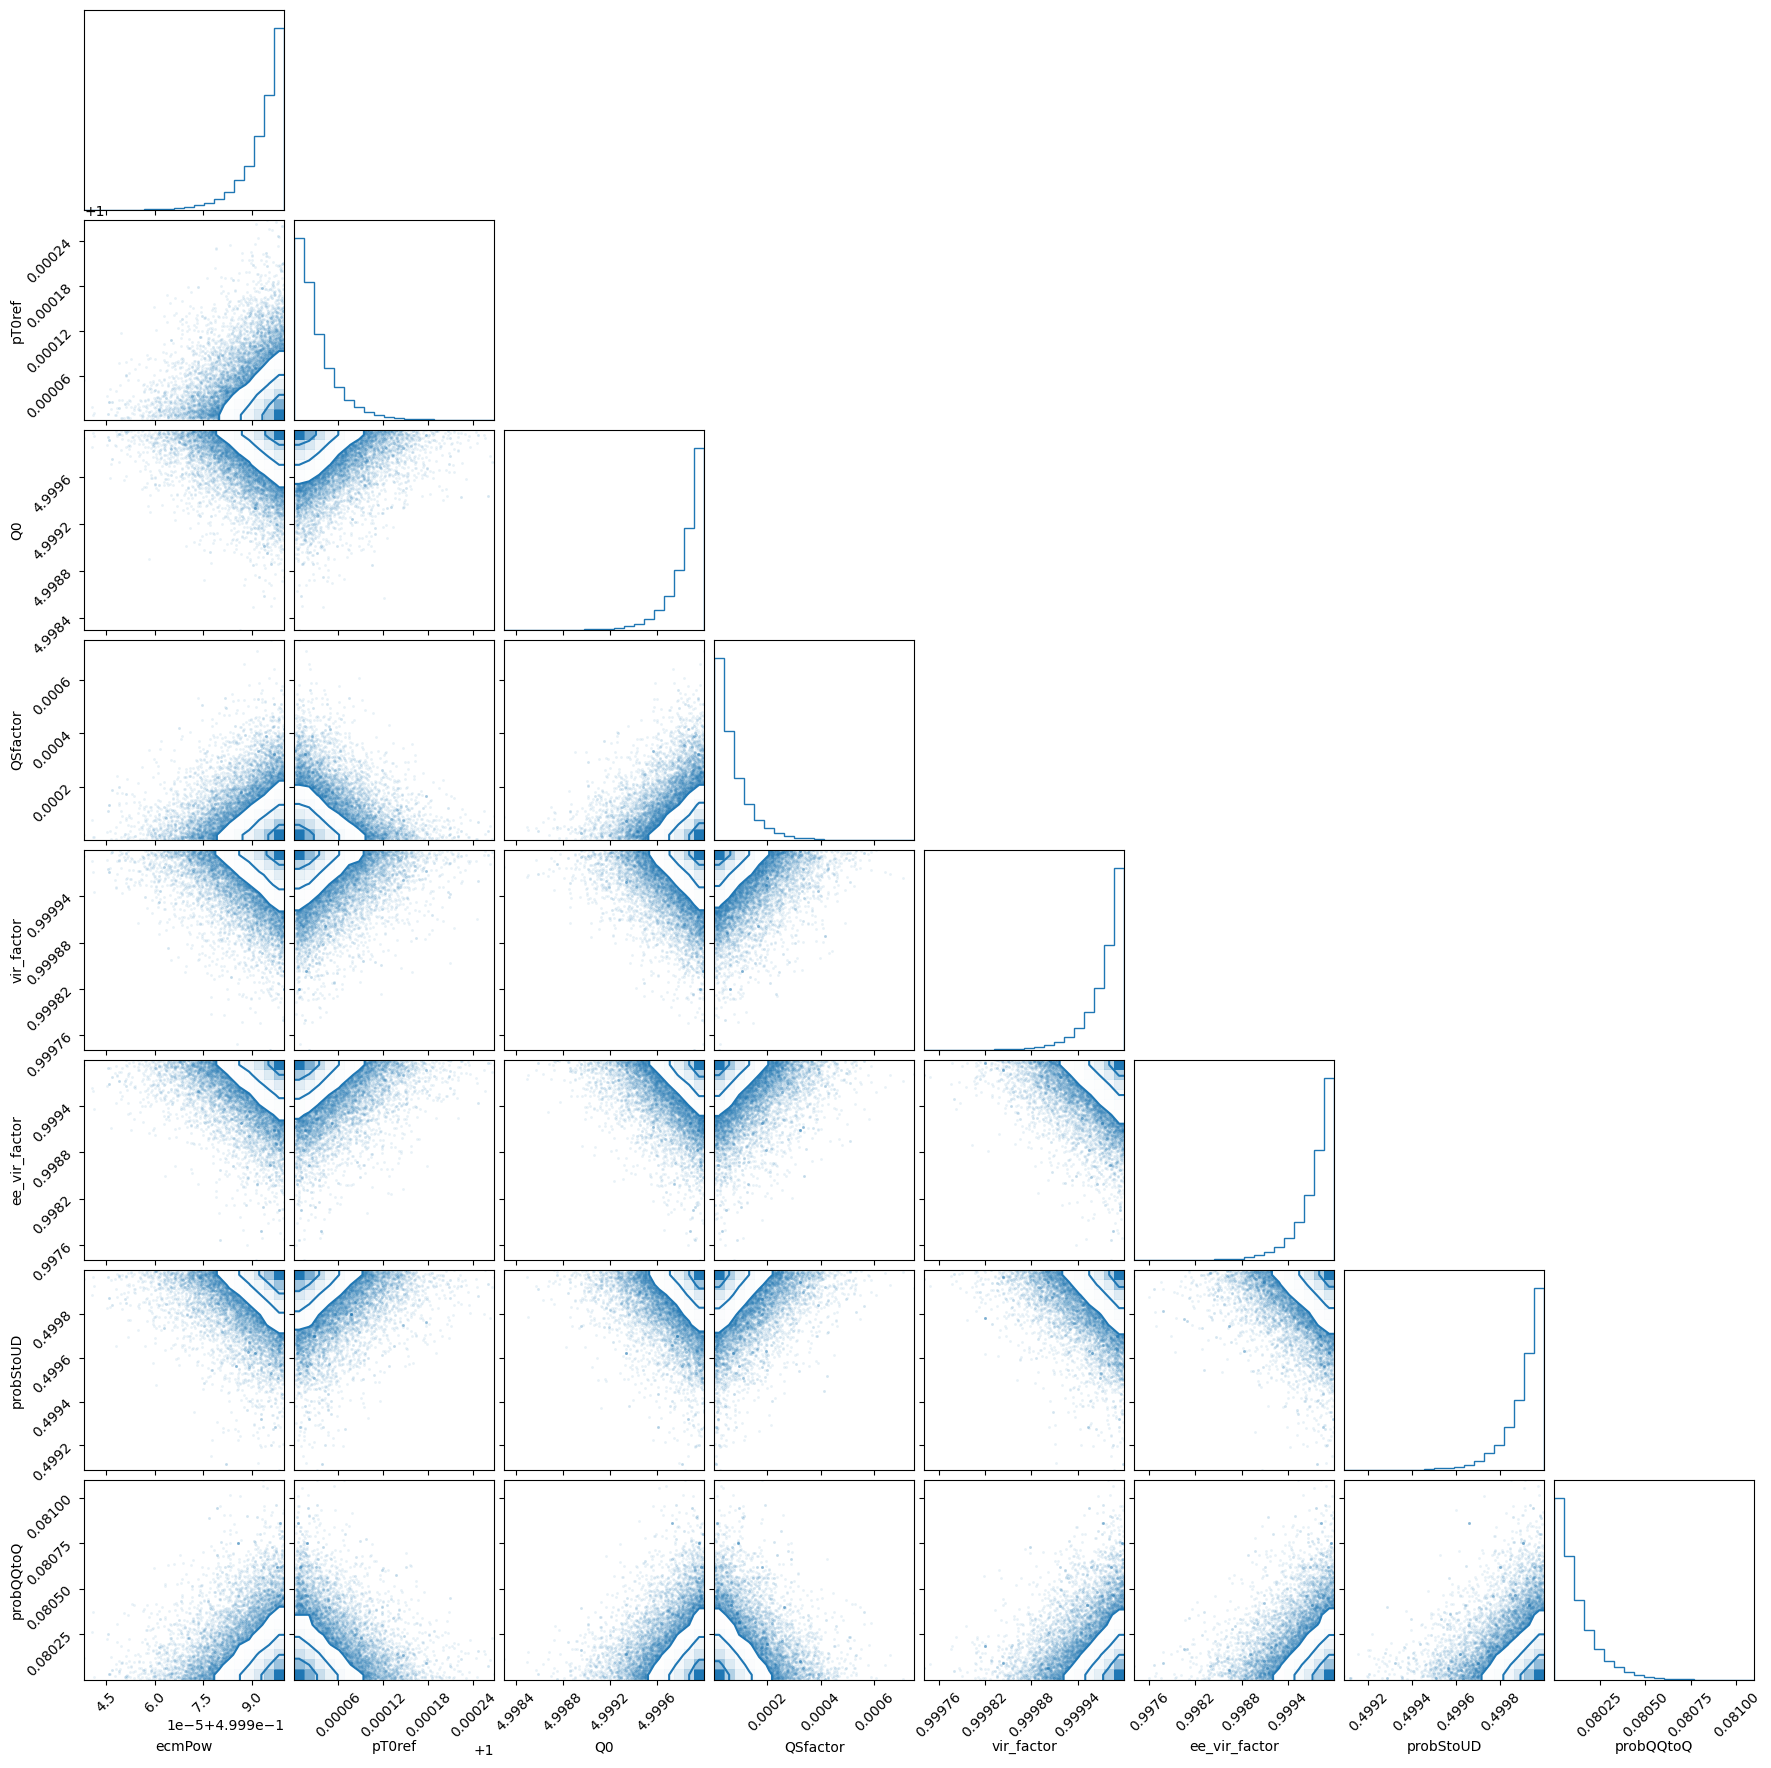

In [8]:
import pickle
import corner
import matplotlib.pyplot as plt
import numpy as np
        
with open(mcmcpath, 'rb') as pf:
        data = pickle.load(pf)

labels = mymcmc.label

fig = corner.corner(data['chain'], weights=data['weights'], labels=labels, color="C0")
plt.show()

In [ ]:
TransformedSamples = np.copy(data['chain'])
TransformedSamples[:,0] = data['chain'][:,0]
TransformedSamples[:,1] = data['chain'][:,1]
TransformedSamples[:,2] = data['chain'][:,2]
TransformedSamples[:,3] = (2*data['chain'][:,6]+0.05) + (data['chain'][:,2]-(2*data['chain'][:,6]+0.05))*data['chain'][:,3]
TransformedSamples[:,4] = data['chain'][:,4]
TransformedSamples[:,5] = data['chain'][:,5]
TransformedSamples[:,6] = data['chain'][:,6]
TransformedSamples[:,7] = data['chain'][:,7]

labels[3] = "QS"
fig = corner.corner(TransformedSamples, weights=data['weights'], labels=labels, color="C0")
plt.show()
fig.savefig(outdir+'Corner.pdf', dpi = 192)

if runchain: bestParams = better_extract_parameters(mymcmc, ThisData["Design"]["Parameter"], outdir)

Priors

In [ ]:
makeplot(ThisData, "Priors", outdir, logTrain=logTrain)

Posteriors

In [ ]:
makeplot(ThisData, "Posteriors", outdir, samples=data["chain"], logTrain=logTrain, scikit=scikit)

Validation

In [ ]:
from src.data_objects import valData

updateCuts(ThisData,valData)
trimRanges(valData)
validationPlots(valData, ThisData, outdir, logTrain=logTrain, scikit=scikit)

Honesty Plots

In [ ]:
ErrorHonestyPlots(valData,ThisData,outdir,logTrain=logTrain,scikit=scikit)

Closure Tests

In [ ]:
closureTest(ThisData, valData, outdir, model_par, runchain=runchain, logTrain=logTrain)